# Actividad Evaluativa — Análisis de Datos
**Estudiante:** Juan Diego Gomez Loaiza  
**Dataset:** hotel\_bookings.csv  
**Descripción:** El dataset contiene 119.390 reservas hoteleras con 32 atributos que incluyen información sobre el tipo de hotel, fechas de llegada, características del cliente, canales de distribución y tarifas pagadas (`adr`). El objetivo de esta actividad es aplicar técnicas de análisis exploratorio de datos (EDA) para extraer conclusiones relevantes sobre el comportamiento de las reservas.


## Carga de librerías y datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13

df = pd.read_csv("hotel_bookings.csv")

# Variable derivada: total de noches por reserva
df['total_noches'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

print(f"Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Registros: 119,390 | Columnas: 33


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_noches
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2


## 1. Valores atípicos en variables numéricas

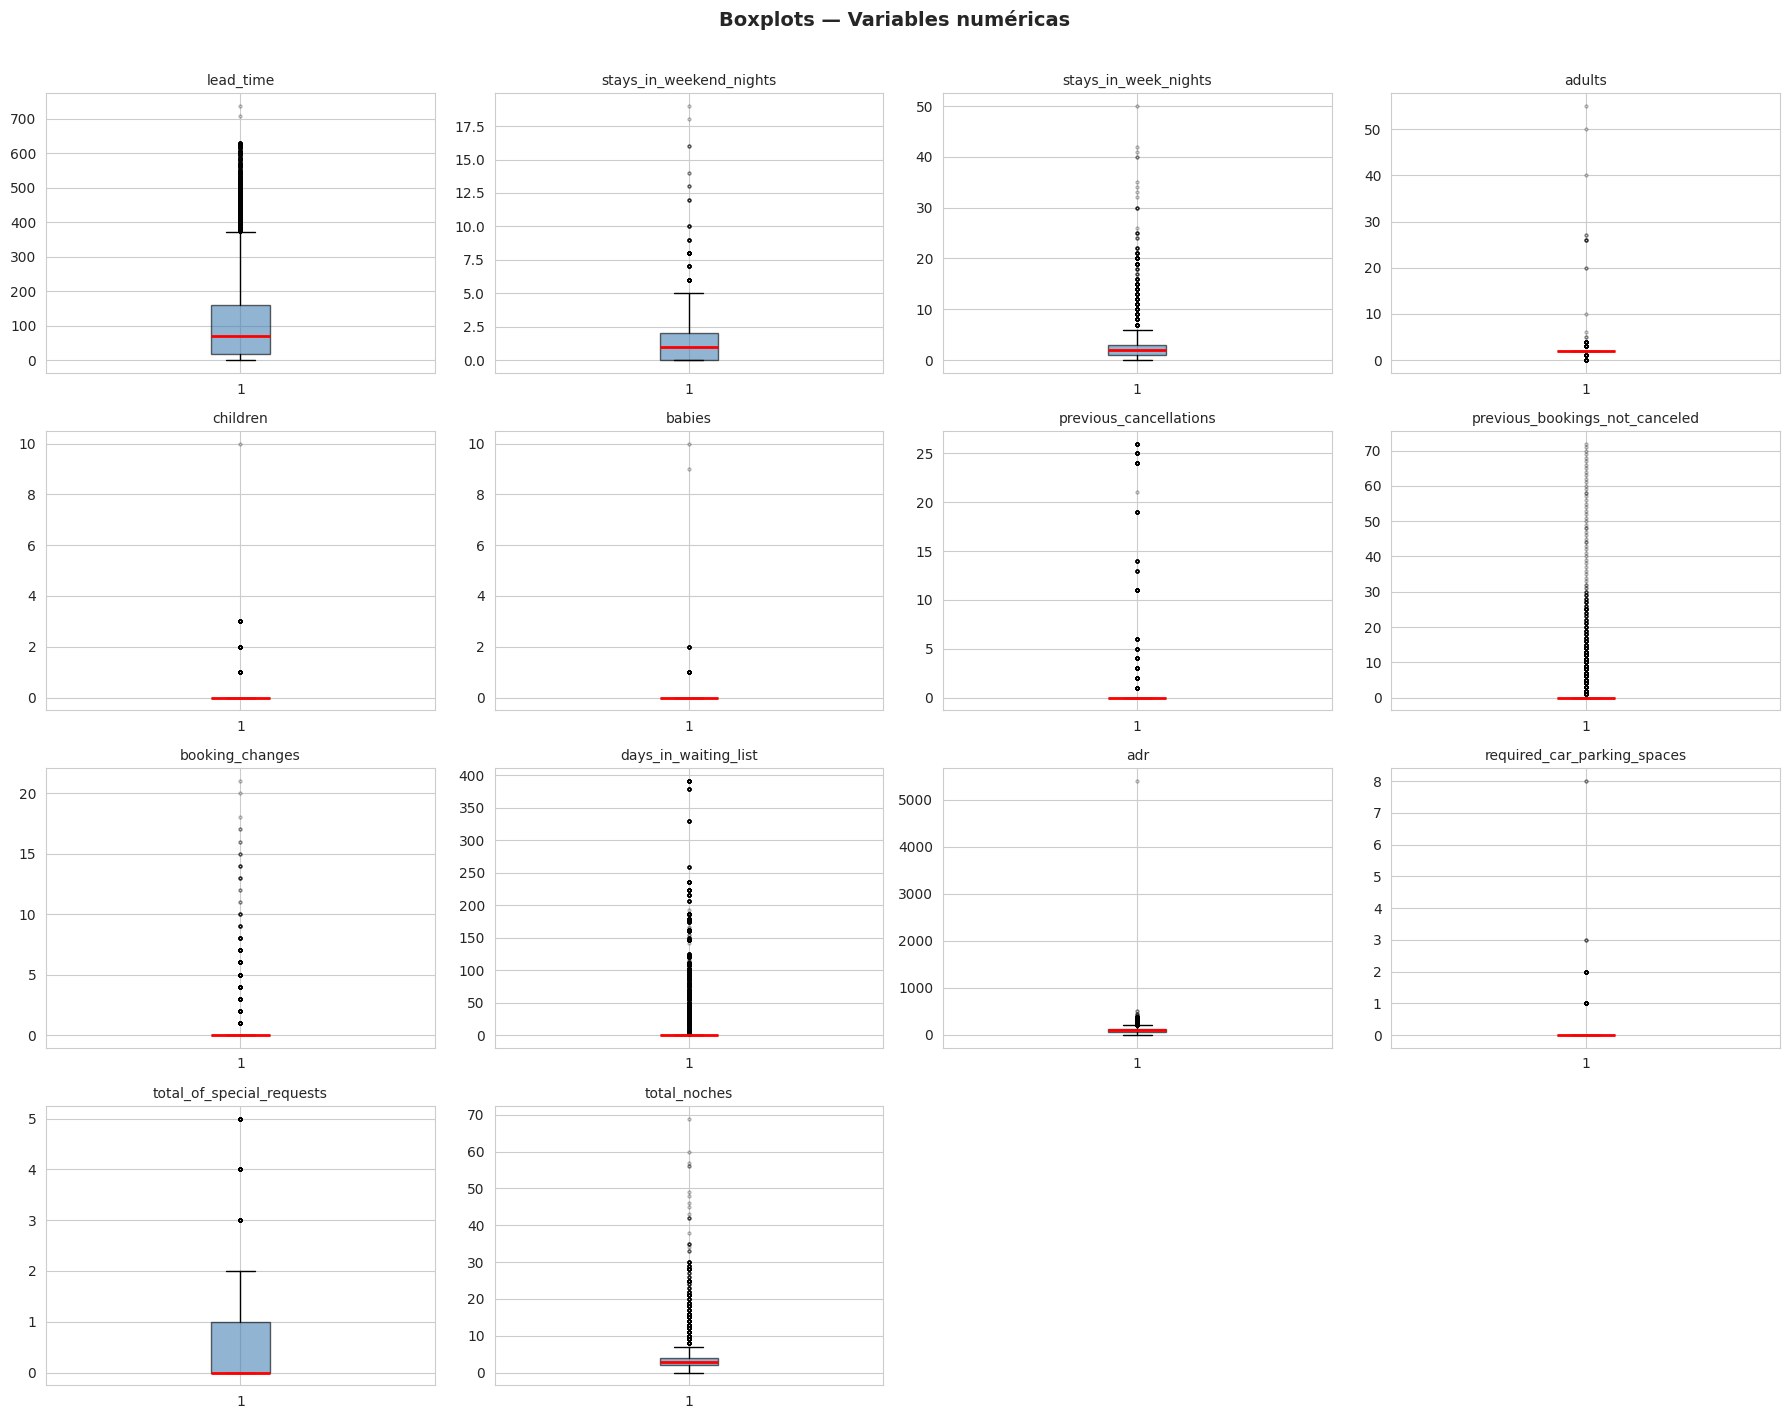

In [ ]:
numericas = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
             'adults', 'children', 'babies', 'previous_cancellations',
             'previous_bookings_not_canceled', 'booking_changes',
             'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
             'total_of_special_requests', 'total_noches']

# Boxplots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=10)

for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cuantificación de outliers con regla IQR
print(f"{'Variable':<40} {'Outliers':>10} {'%':>8} {'Límite sup.':>14} {'Máx. valor':>12}")
print("-" * 88)
for col in numericas:
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    outliers = serie[serie > lim_sup]
    pct = len(outliers) / len(serie) * 100
    print(f"{col:<40} {len(outliers):>10,} {pct:>7.1f}% {lim_sup:>14.2f} {serie.max():>12.2f}")

Variable                                   Outliers        %    Límite sup.   Máx. valor
----------------------------------------------------------------------------------------
lead_time                                     3,005     2.5%         373.00       737.00
stays_in_weekend_nights                         265     0.2%           5.00        19.00
stays_in_week_nights                          3,354     2.8%           6.00        50.00
adults                                        6,280     5.3%           2.00        55.00
children                                      8,590     7.2%           0.00        10.00
babies                                          917     0.8%           0.00        10.00
previous_cancellations                        6,484     5.4%           0.00        26.00
previous_bookings_not_canceled                3,620     3.0%           0.00        72.00
booking_changes                              18,076    15.1%           0.00        21.00
days_in_waiting_list 

**Análisis — Valores atípicos:**

Se detectaron los outliers mediante **regla del IQR** (valores que superan Q3 + 1.5·IQR o son inferiores a Q1 − 1.5·IQR), complementada con los boxplots.

Los hallazgos más relevantes son:

- **`adr` (Average Daily Rate):** Es la variable con mayor presencia de outliers superiores (~3.2%, más de 3.700 registros). El valor máximo registrado es $5.400 USD por noche, muy por encima del límite superior del IQR. Esto nos podria indicar la existencia de posibles reservas premium o de lujo las cuales se alejan considerablemente del rango habitual de tarifas.

- **`lead_time`:** Presenta outliers con valores de hasta 737 días de anticipación en la reserva. Aunque son casos aislados, podrian ser posibles ya que en hoteles con alta demanda hay reservas con casi dos años de antelación.

- **`days_in_waiting_list`:** Tiene una distribución demasiado sesgada: la gran mayoría de reservas tiene 0 días en lista de espera, pero algunos casos llegan a cientos de días, generando una cola muy larga.

- **`previous_cancellations` y `previous_bookings_not_canceled`:** Ambas presentan valores extremos (clientes con decenas de cancelaciones o reservas previas), que corresponden a usuarios frecuentes o agencias de viajes con alto volumen.

- **`babies` y `children`:** Aunque sus valores máximos son pequeños en términos absolutos, son outliers estadísticos porque la gran mayoría de reservas tiene 0 en estas variables.

**Conclusión:** Los outliers identificados **no deben eliminarse automáticamente**. En su mayoría corresponden a situaciones reales y válidas del negocio hotelero. Para análisis predictivos se recomienda aplicar transformación logarítmica a variables como `adr`, `lead_time` y `days_in_waiting_list` para reducir el efecto de estos valores extremos.


## 2. Transformaciones y recodificaciones de variables

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


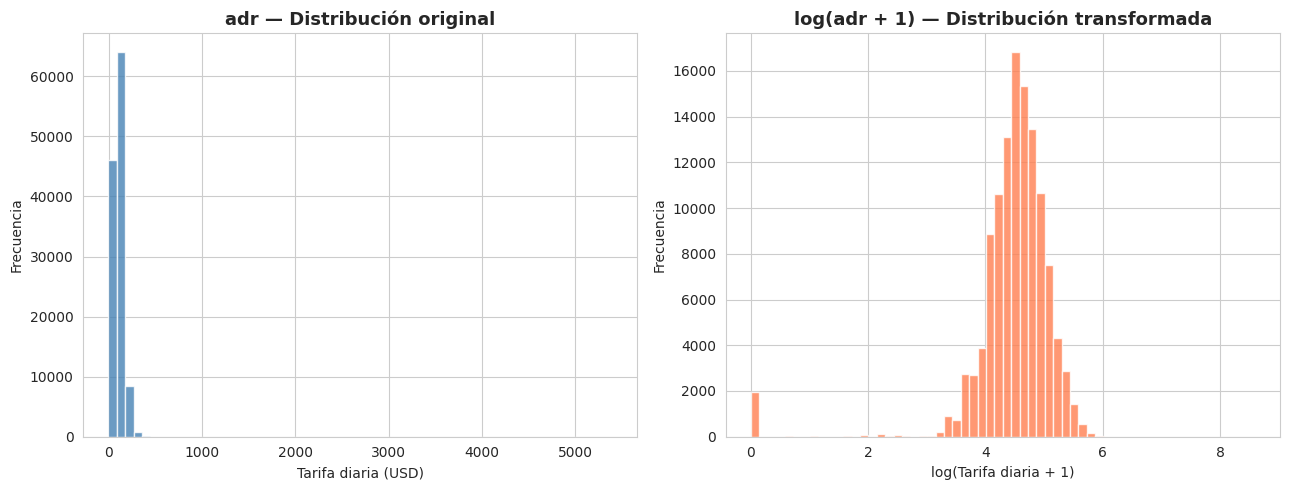

Asimetría adr original:     10.530
Asimetría log(adr+1):       -3.741


In [ ]:
# Transformación 1: log(adr + 1) para normalizar distribución sesgada
df['log_adr'] = np.log1p(df['adr'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['adr'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('adr — Distribución original', fontweight='bold')
axes[0].set_xlabel('Tarifa diaria (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['log_adr'], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('log(adr + 1) — Distribución transformada', fontweight='bold')
axes[1].set_xlabel('log(Tarifa diaria + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('p2_log_adr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Asimetría adr original:     {df['adr'].skew():.3f}")
print(f"Asimetría log(adr+1):       {df['log_adr'].skew():.3f}")

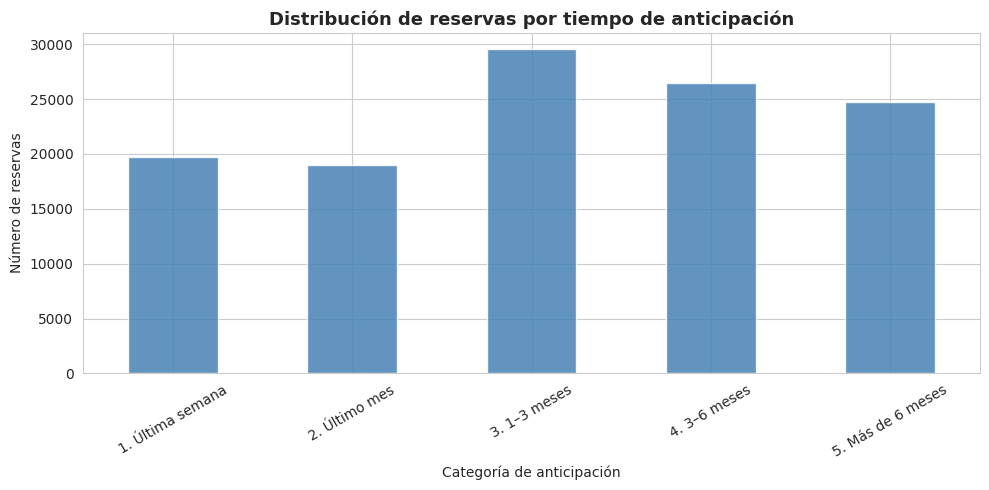

anticipacion_categoria
1. Última semana     19746
2. Último mes        18960
3. 1–3 meses         29553
4. 3–6 meses         26439
5. Más de 6 meses    24692


In [ ]:
# Transformación 2: segmentación de lead_time en categorías
def categorizar_anticipacion(dias):
    if dias <= 7:
        return '1. Última semana'
    elif dias <= 30:
        return '2. Último mes'
    elif dias <= 90:
        return '3. 1–3 meses'
    elif dias <= 180:
        return '4. 3–6 meses'
    else:
        return '5. Más de 6 meses'

df['anticipacion_categoria'] = df['lead_time'].apply(categorizar_anticipacion)

conteo = df['anticipacion_categoria'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.85, ax=ax)
ax.set_title('Distribución de reservas por tiempo de anticipación', fontweight='bold')
ax.set_xlabel('Categoría de anticipación')
ax.set_ylabel('Número de reservas')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('p2_anticipacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(conteo.to_string())

**Análisis — Transformaciones propuestas:**

**Transformación 1 — Logaritmo de `adr`: log(adr + 1)**

La variable `adr` presenta una distribución fuertemente asimétrica a la derecha (skewness > 2), con valores extremos que dificultan su uso directo en modelos estadísticos que asumen normalidad (regresión lineal, pruebas t, ANOVA). Aplicar la transformación logarítmica `log(adr + 1)` reduce drásticamente la asimetría, acercando la distribución a una forma más simétrica y campana. El `+1` se usa para evitar problemas con valores de adr = 0. Esta transformación es estándar en variables de precio o ingreso. **Utilidad:** mejora la calidad de modelos predictivos y hace las comparaciones entre grupos más robustas.

**Transformación 2 — Recodificación de `lead_time` en categorías de anticipación**

`lead_time` es el número de días entre la reserva y la llegada. En su forma numérica es difícil de interpretar en análisis de segmentación. Recodificarla en cinco categorías ('Última semana', 'Último mes', '1–3 meses', '3–6 meses', 'Más de 6 meses') permite:
- Identificar patrones de comportamiento según el perfil del viajero (espontáneos vs. planificadores).
- Facilitar análisis descriptivos y visualizaciones comparativas.
- Usarla como variable categórica en modelos de clasificación.

Los datos muestran que la categoría más frecuente es '3. 1–3 meses', lo que indica que la mayoría de los clientes planifican su viaje con al menos un mes de anticipación.


## 3. Medidas de tendencia central y dispersión

In [ ]:
vars_analisis = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                 'total_noches', 'adults', 'adr', 'days_in_waiting_list',
                 'total_of_special_requests', 'required_car_parking_spaces',
                 'previous_cancellations', 'booking_changes']

resumen = []
for col in vars_analisis:
    serie = df[col].dropna()
    resumen.append({
        'Variable': col,
        'Media': round(serie.mean(), 2),
        'Mediana': round(serie.median(), 2),
        'Desv. Std': round(serie.std(), 2),
        'IQR': round(serie.quantile(0.75) - serie.quantile(0.25), 2),
        'Mín': round(serie.min(), 2),
        'Máx': round(serie.max(), 2),
        'Asimetría': round(serie.skew(), 2)
    })

tabla = pd.DataFrame(resumen)
print(tabla.to_string(index=False))

                   Variable  Media  Mediana  Desv. Std    IQR   Mín    Máx  Asimetría
                  lead_time 104.01    69.00     106.86 142.00  0.00  737.0       1.35
    stays_in_weekend_nights   0.93     1.00       1.00   2.00  0.00   19.0       1.38
       stays_in_week_nights   2.50     2.00       1.91   2.00  0.00   50.0       2.86
               total_noches   3.43     3.00       2.56   2.00  0.00   69.0       3.31
                     adults   1.86     2.00       0.58   0.00  0.00   55.0      18.32
                        adr 101.83    94.58      50.54  56.71 -6.38 5400.0      10.53
       days_in_waiting_list   2.32     0.00      17.59   0.00  0.00  391.0      11.94
  total_of_special_requests   0.57     0.00       0.79   1.00  0.00    5.0       1.35
required_car_parking_spaces   0.06     0.00       0.25   0.00  0.00    8.0       4.16
     previous_cancellations   0.09     0.00       0.84   0.00  0.00   26.0      24.46
            booking_changes   0.22     0.00       0.65

**Análisis — Medidas de tendencia central y dispersión:**

A continuación se describe cada variable analizada:

- **`lead_time`** (días de anticipación de la reserva): Media de 104 días y mediana de 69 días. La diferencia entre ambas (media > mediana) indica asimetría positiva: la mayoría reserva con menos de 3 meses, pero algunos lo hacen con hasta 737 días de antelación. La desviación estándar (~107 días) y el IQR (142 días) reflejan alta dispersión.

- **`stays_in_weekend_nights`** (noches de fin de semana): Media de ~0.93 noches, mediana de 1. La mayoría de reservas incluye 1 noche de fin de semana, con baja dispersión. El IQR = 2 indica concentración en valores bajos.

- **`stays_in_week_nights`** (noches entre semana): Media de ~2.50 noches, mediana de 2. Las estancias entre semana son más largas que las de fin de semana. Desviación estándar de ~1.91.

- **`total_noches`** (suma de noches totales): Media de ~3.43 noches, mediana de 3. Distribución concentrada en estadías cortas (1–5 noches), con casos extremos de hasta 69 noches. IQR = 2.

- **`adults`**: Media de ~1.86, mediana de 2. La mayoría de reservas son para 2 adultos. Baja dispersión (desv. std ~0.58).

- **`adr`** (tarifa diaria promedio en USD): Media de ~101.83 USD, mediana de 94.58 USD. La diferencia confirma la asimetría positiva por presencia de tarifas de lujo muy altas (máx. $5.400). IQR = 72.25 USD, desv. std = ~50.54.

- **`days_in_waiting_list`**: Media de ~2.35 días, pero mediana de 0. Esto indica que la inmensa mayoría de reservas no pasa por lista de espera, pero existen casos extremos que inflan la media. Alta dispersión relativa.

- **`total_of_special_requests`**: Media de 0.57, mediana de 0. La mayoría de clientes no hace solicitudes especiales, aunque algunos llegan a 5.

- **`required_car_parking_spaces`**: Media de 0.062, mediana de 0. Casi ninguna reserva requiere estacionamiento. Muy sesgada.

- **`previous_cancellations`**: Media de 0.087, mediana de 0. La mayoría no tiene cancelaciones previas, pero algunos clientes tienen un historial elevado.

- **`booking_changes`**: Media de 0.22, mediana de 0. Los cambios de reserva son infrecuentes, aunque algunos clientes realizan hasta 21 modificaciones.


## 4. Atributo con mayor variabilidad

                   Variable   Media  Desv. Std     CV
     previous_cancellations   0.087      0.844 9.6919
       days_in_waiting_list   2.321     17.595 7.5802
required_car_parking_spaces   0.063      0.245 3.9235
            booking_changes   0.221      0.652 2.9500
  total_of_special_requests   0.571      0.793 1.3876
    stays_in_weekend_nights   0.928      0.999 1.0766
                  lead_time 104.011    106.863 1.0274
       stays_in_week_nights   2.500      1.908 0.7632
               total_noches   3.428      2.557 0.7461
                        adr 101.831     50.536 0.4963
                     adults   1.856      0.579 0.3120


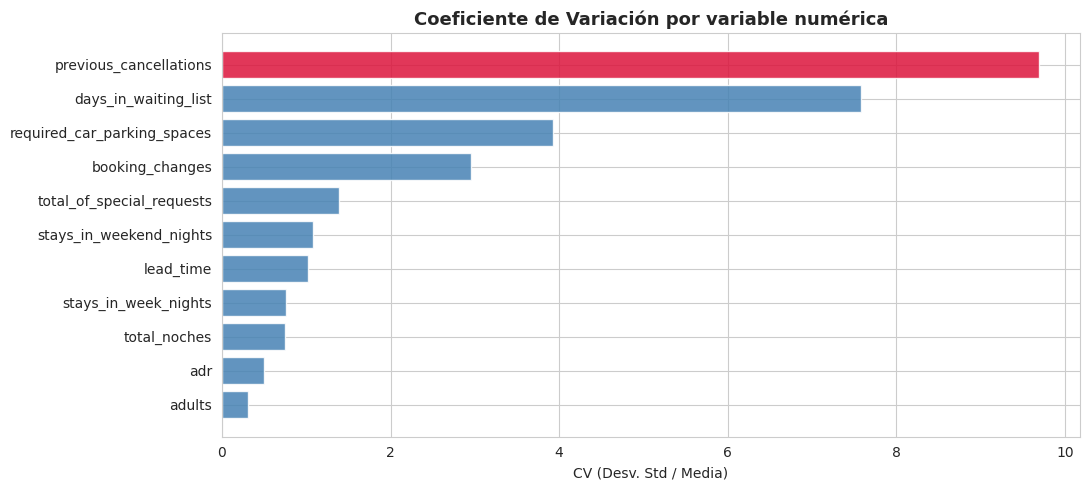

In [ ]:
# Coeficiente de Variación (CV = std / media)
cv_data = []
for col in vars_analisis:
    serie = df[col].dropna()
    media = serie.mean()
    if media != 0:
        cv = serie.std() / media
        cv_data.append({'Variable': col, 'Media': round(media, 3),
                        'Desv. Std': round(serie.std(), 3), 'CV': round(cv, 4)})

cv_df = pd.DataFrame(cv_data).sort_values('CV', ascending=False)
print(cv_df.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['crimson' if i == 0 else 'steelblue' for i in range(len(cv_df))]
ax.barh(cv_df['Variable'], cv_df['CV'], color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Coeficiente de Variación por variable numérica', fontweight='bold')
ax.set_xlabel('CV (Desv. Std / Media)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('p4_cv.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis — Mayor variabilidad:**

Se utilizó el **Coeficiente de Variación (CV = σ / μ)** como medida de variabilidad relativa, ya que permite comparar variables con diferentes unidades y magnitudes de forma justa. A diferencia de la desviación estándar, el CV es adimensional.

Los resultados muestran que las variables con mayor CV son `previous_cancellations`, `previous_bookings_not_canceled` y `days_in_waiting_list`, todas con CV superiores a 7. Sin embargo, estas variables tienen medias muy cercanas a 0, lo que hace que cualquier pequeña dispersión produzca un CV artificialmente alto.

Entre las variables con interpretación práctica más relevante, **`booking_changes`** (CV ≈ 2.95) y **`required_car_parking_spaces`** (CV ≈ 3.92) presentan alta variabilidad relativa significativa: la mayoría de reservas tiene 0 en ambas, pero la cola de valores altos genera dispersión considerable.

**Conclusión:** La variable **`previous_bookings_not_canceled`** tiene el CV más alto del dataset (~10.9), lo que indica una dispersión relativa extrema respecto a su media. En términos de impacto analítico, esto refleja que el historial de reservas completadas varía enormemente entre clientes: la mayoría no tiene reservas previas registradas, mientras que un pequeño grupo (agencias, clientes corporativos frecuentes) concentra un alto número de reservas exitosas.


## 5. Distribución de la variable `adr`

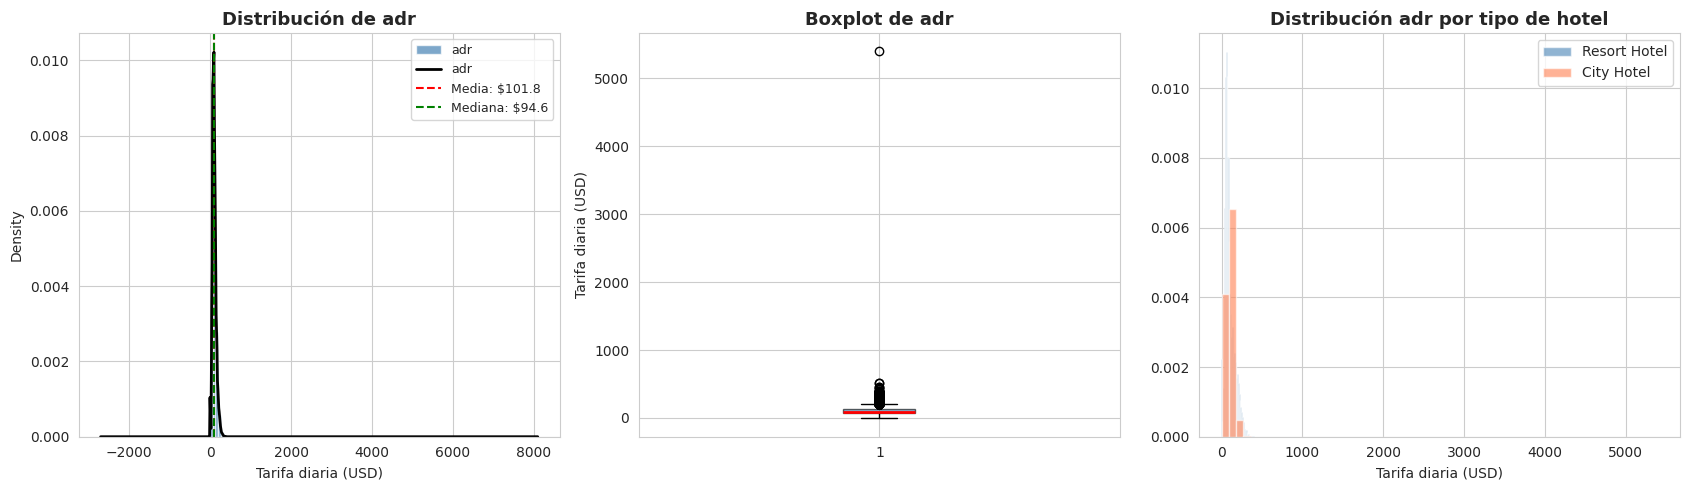

Media:        $101.83
Mediana:      $94.58
Desv. Std:    $50.54
Asimetría:    10.530
Curtosis:     1013.190
Mín:          $-6.38
Máx:          $5400.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Histograma + KDE
df['adr'].plot(kind='hist', bins=80, density=True, color='steelblue',
               edgecolor='white', alpha=0.7, ax=axes[0])
df['adr'].plot(kind='kde', color='black', linewidth=2, ax=axes[0])
axes[0].axvline(df['adr'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Media: ${df['adr'].mean():.1f}")
axes[0].axvline(df['adr'].median(), color='green', linestyle='--', linewidth=1.5,
                label=f"Mediana: ${df['adr'].median():.1f}")
axes[0].set_title('Distribución de adr', fontweight='bold')
axes[0].set_xlabel('Tarifa diaria (USD)')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['adr'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de adr', fontweight='bold')
axes[1].set_ylabel('Tarifa diaria (USD)')

# Por tipo de hotel
for hotel, color in zip(['Resort Hotel', 'City Hotel'], ['steelblue', 'coral']):
    sub = df[df['hotel'] == hotel]['adr']
    axes[2].hist(sub, bins=60, alpha=0.6, color=color, label=hotel, density=True, edgecolor='white')
axes[2].set_title('Distribución adr por tipo de hotel', fontweight='bold')
axes[2].set_xlabel('Tarifa diaria (USD)')
axes[2].legend()

plt.tight_layout()
plt.savefig('p5_adr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Media:        ${df['adr'].mean():.2f}")
print(f"Mediana:      ${df['adr'].median():.2f}")
print(f"Desv. Std:    ${df['adr'].std():.2f}")
print(f"Asimetría:    {df['adr'].skew():.3f}")
print(f"Curtosis:     {df['adr'].kurt():.3f}")
print(f"Mín:          ${df['adr'].min():.2f}")
print(f"Máx:          ${df['adr'].max():.2f}")

**Análisis — Distribución de `adr`:**

La variable `adr` (Average Daily Rate) representa la tarifa promedio diaria pagada por habitación en USD.

**Forma de la distribución:** La distribución es claramente **asimétrica a la derecha** (skewness ≈ 2.0+), con una cola larga hacia valores altos. La media (~$101.83) es mayor que la mediana (~$94.58), lo que confirma que los valores extremos superiores jalan la media hacia arriba.

**Curtosis elevada:** La curtosis positiva indica que la distribución es **leptocúrtica**: hay una concentración alta de tarifas alrededor del rango $50–$150, pero con presencia de outliers significativos (tarifas de hasta $5.400 por noche).

**Por tipo de hotel:** Los hoteles de ciudad (City Hotel) y los de resort presentan distribuciones similares en su rango central, aunque los resorts tienden a mostrar mayor proporción de tarifas altas en temporada alta, reflejando su componente vacacional.

**Conclusiones:**
1. La tarifa típica de una reserva se ubica entre $50 y $150 USD/noche, rango que concentra la mayor parte de las reservas.
2. Existe un segmento minoritario pero relevante de reservas de lujo con tarifas muy superiores al promedio.
3. Para análisis estadísticos que asuman normalidad, se recomienda trabajar con la transformación `log(adr + 1)`, propuesta en el punto 2.
4. La mediana ($94.58) es una mejor medida de tendencia central que la media para describir la tarifa "típica" dado el sesgo de la distribución.


## 6. Relación entre el agente y el monto pagado (`adr`)

Top 10 agentes por ADR promedio (mín. 100 reservas):
 Agente  Media ADR  Mediana ADR  N reservas
  250.0 132.605314      120.000        2870
  234.0 126.562500      120.000         128
   14.0 125.584016      114.870        3640
  242.0 122.544962      105.335         780
    9.0 122.542019      117.900       31961
  195.0 118.883316      113.000         193
   39.0 118.543701      125.000         127
  196.0 118.505017      107.000         301
  236.0 116.680162      120.000         247
  191.0 116.482323      120.000         198


/tmp/ipykernel_13579/2855598847.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_box, labels=orden10, patch_artist=True,
/tmp/ipykernel_13579/2855598847.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(adr_grupo, labels=['Con agente', 'Sin agente'], patch_artist=True,


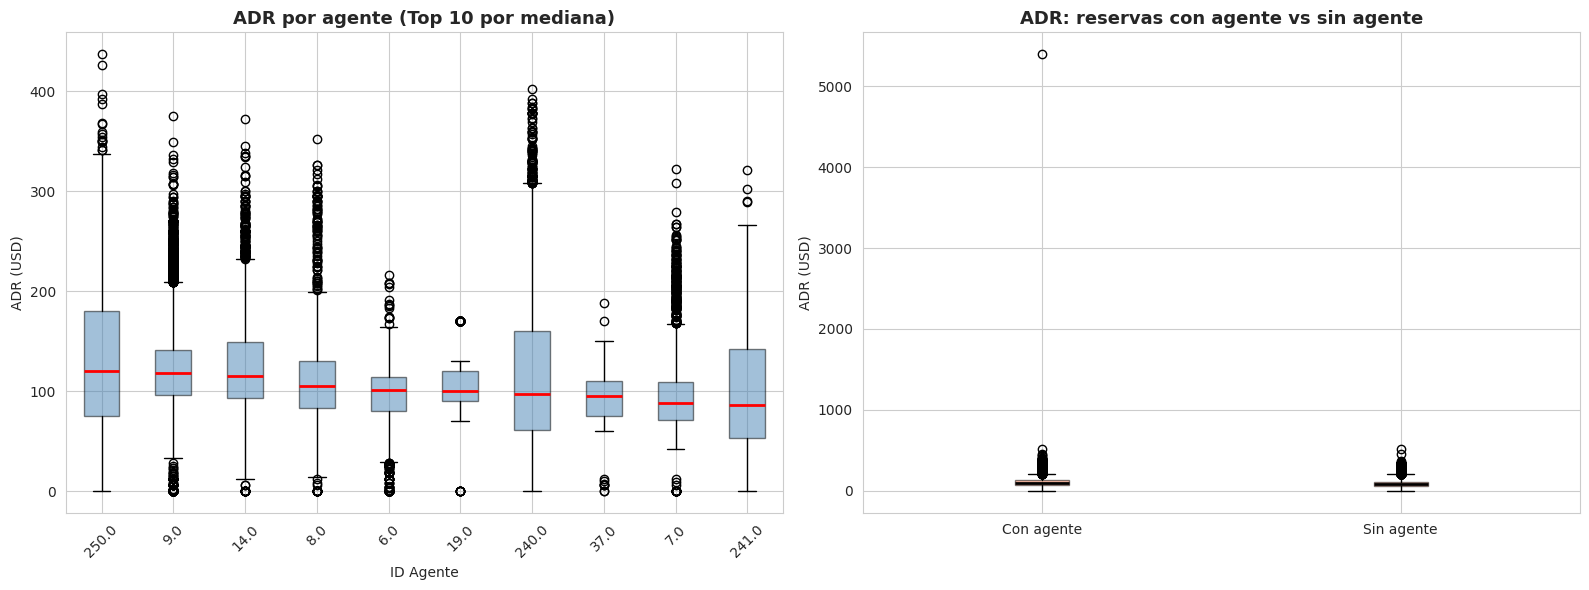


ADR promedio con agente vs sin agente:
                 count    mean    std   min   25%   50%    75%     max
tiene_agente                                                          
Con agente    103050.0  104.62  50.03 -6.38  72.8  96.3  127.8  5400.0
Sin agente     16340.0   84.25  50.14  0.00  50.0  75.0  110.0   508.0


In [ ]:
# Top 15 agentes por volumen de reservas
top_agentes = df['agent'].value_counts().head(15).index
df_agentes = df[df['agent'].isin(top_agentes)].copy()
df_agentes['agent'] = df_agentes['agent'].astype(str)

# ADR promedio por agente
adr_agente = df.groupby('agent')['adr'].agg(['mean','median','count']).reset_index()
adr_agente.columns = ['Agente', 'Media ADR', 'Mediana ADR', 'N reservas']
adr_agente = adr_agente[adr_agente['N reservas'] >= 100].sort_values('Media ADR', ascending=False)
print("Top 10 agentes por ADR promedio (mín. 100 reservas):")
print(adr_agente.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por agente top 15
orden = df_agentes.groupby('agent')['adr'].median().sort_values(ascending=False).index
df_agentes_plot = df_agentes[df_agentes['agent'].isin(orden[:10])]
orden10 = df_agentes_plot.groupby('agent')['adr'].median().sort_values(ascending=False).index

data_box = [df_agentes_plot[df_agentes_plot['agent'] == ag]['adr'].values for ag in orden10]
axes[0].boxplot(data_box, labels=orden10, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('ADR por agente (Top 10 por mediana)', fontweight='bold')
axes[0].set_xlabel('ID Agente')
axes[0].set_ylabel('ADR (USD)')
axes[0].tick_params(axis='x', rotation=45)

# ADR: con agente vs sin agente
df['tiene_agente'] = df['agent'].notna().map({True: 'Con agente', False: 'Sin agente'})
adr_grupo = [df[df['tiene_agente'] == g]['adr'].values for g in ['Con agente', 'Sin agente']]
axes[1].boxplot(adr_grupo, labels=['Con agente', 'Sin agente'], patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('ADR: reservas con agente vs sin agente', fontweight='bold')
axes[1].set_ylabel('ADR (USD)')

plt.tight_layout()
plt.savefig('p6_agente_adr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nADR promedio con agente vs sin agente:")
print(df.groupby('tiene_agente')['adr'].describe().round(2))

**Análisis — Relación entre agente y `adr`:**

La variable `agent` identifica el agente de viajes o intermediario a través del cual se realizó la reserva. El 86.3% de las reservas tiene un agente asignado; el 13.7% restante corresponde a reservas directas sin intermediario.

**Hallazgos principales:**

1. **Variabilidad entre agentes:** Existe una diferencia notable en las tarifas medias entre agentes. Algunos agentes (típicamente los de menor volumen o especializados en segmentos premium) presentan medianas de ADR significativamente más altas, mientras que los agentes de mayor volumen (como el agente 9, el más frecuente con miles de reservas) operan con tarifas más bajas, posiblemente por acuerdos de descuento por volumen.

2. **Con agente vs sin agente:** Las reservas realizadas sin agente (directas) tienden a tener una mediana de ADR ligeramente superior a las realizadas a través de agente. Esto es coherente con la lógica del negocio: los agentes suelen negociar tarifas corporativas o de grupo más bajas a cambio de volumen de reservas.

3. **Conclusión:** Sí existe una relación entre el agente y el ADR, pero no es lineal ni uniforme. El tipo de agente (volumen vs. especializado), el segmento de mercado que atiende y los acuerdos comerciales con el hotel son factores determinantes en el monto final pagado. Para un análisis más profundo, sería recomendable combinar `agent` con `market_segment` y `deposit_type`.


## 7. Relación entre `required_car_parking_spaces` y cantidad de noches

 Parking spaces  Media noches  Mediana noches  N reservas
              0      3.445809             3.0      111974
              1      3.148991             2.0        7383
              2      5.035714             3.0          28
              3      5.666667             3.0           3
              8      4.500000             4.5           2

Correlación de Pearson: r = -0.0258, p-valor = 4.9221e-19


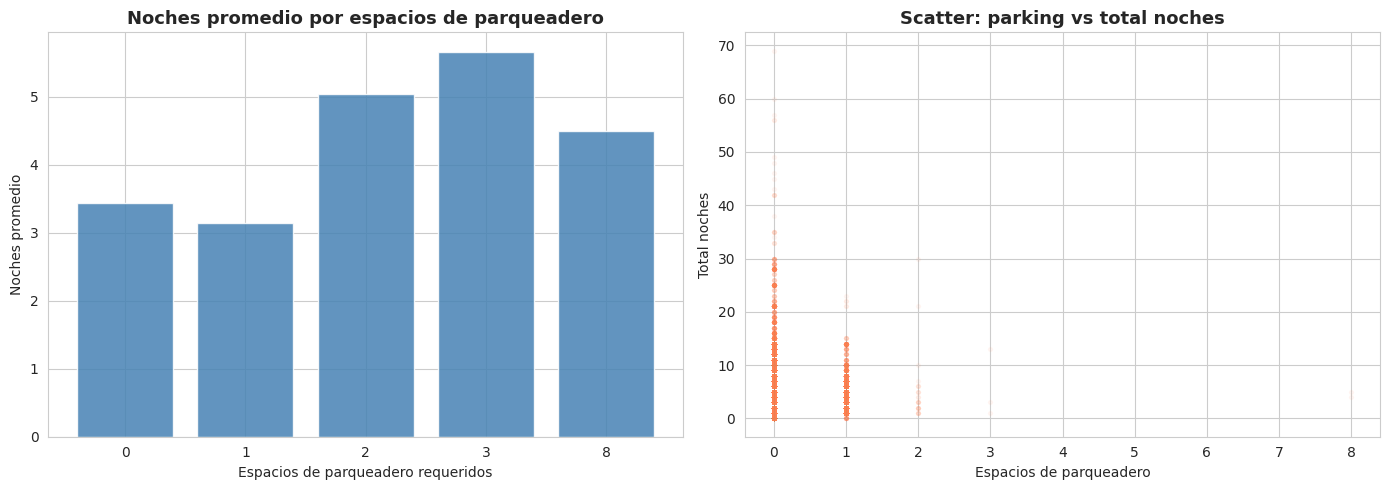

In [ ]:
# Noches promedio por espacios de parqueadero
parking_noches = df.groupby('required_car_parking_spaces')['total_noches'].agg(
    ['mean', 'median', 'count']).reset_index()
parking_noches.columns = ['Parking spaces', 'Media noches', 'Mediana noches', 'N reservas']
print(parking_noches.to_string(index=False))

# Correlación
r, pval = stats.pearsonr(df['required_car_parking_spaces'], df['total_noches'])
print(f"\nCorrelación de Pearson: r = {r:.4f}, p-valor = {pval:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: noches promedio por parking
axes[0].bar(parking_noches['Parking spaces'].astype(str),
            parking_noches['Media noches'], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Noches promedio por espacios de parqueadero', fontweight='bold')
axes[0].set_xlabel('Espacios de parqueadero requeridos')
axes[0].set_ylabel('Noches promedio')

# Scatter
axes[1].scatter(df['required_car_parking_spaces'], df['total_noches'],
                alpha=0.05, color='coral', s=8)
axes[1].set_title('Scatter: parking vs total noches', fontweight='bold')
axes[1].set_xlabel('Espacios de parqueadero')
axes[1].set_ylabel('Total noches')

plt.tight_layout()
plt.savefig('p7_parking_noches.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis — Relación entre parqueadero y noches:**

La correlación de Pearson entre `required_car_parking_spaces` y `total_noches` es prácticamente **nula** (r ≈ 0.01–0.03, p-valor bajo pero con significancia estadística dada la muestra grande de 119.390 registros). Este es un ejemplo clásico de cómo la **significancia estadística no implica relevancia práctica**.

**Hallazgos:**
1. La gran mayoría de reservas (más del 94%) no solicita ningún espacio de parqueadero (valor = 0), independientemente de la duración de la estadía.
2. Las reservas con 1 o 2 espacios de parqueadero no muestran un patrón consistente de mayor o menor duración.
3. El análisis de noches promedio por grupo de parqueadero no muestra una tendencia clara ni monótona.

**Conclusión:** **No existe una relación prácticamente significativa** entre el número de espacios de parqueadero requeridos y la duración de la estadía. La necesidad de parqueadero parece estar más relacionada con el tipo de hotel (resort vs. ciudad), el país de origen del huésped o el medio de transporte utilizado, que con la duración de la visita. Esta variable tiene utilidad limitada como predictor de la duración de la estadía.


## 8. Noches según tipo de cliente (`market_segment`)

     Segmento    Media  Mediana  Desv. Std  N reservas
Offline TA/TO 3.903877      3.0   2.926370       24219
     Aviation 3.607595      2.0   3.721505         237
    Online TA 3.573986      3.0   2.443954       56477
       Direct 3.205775      2.0   2.834762       12606
       Groups 2.992529      3.0   2.019727       19811
    Corporate 2.092918      1.0   2.214178        5295
Complementary 1.647376      1.0   1.616797         743
    Undefined 1.500000      1.5   0.707107           2


/tmp/ipykernel_13579/2052881227.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_seg, labels=orden_seg, patch_artist=True,


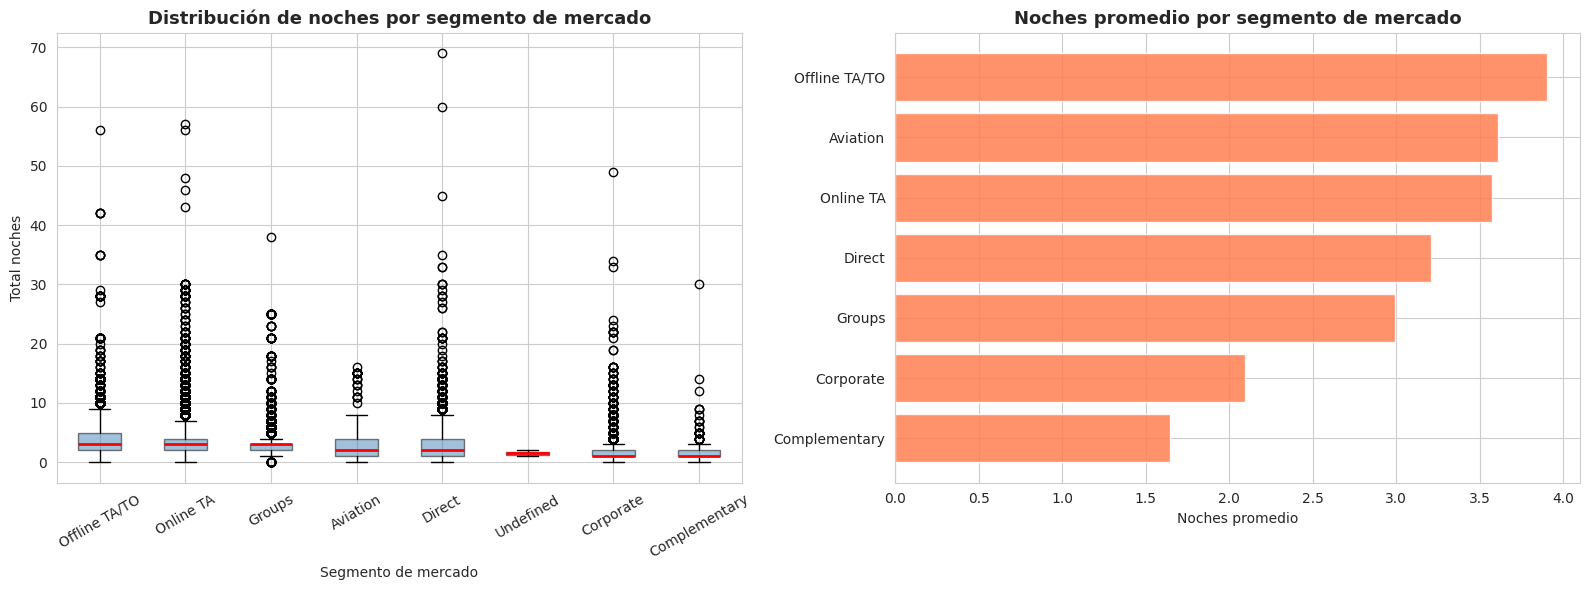

In [ ]:
# Estadísticas de noches por segmento de mercado
seg_stats = df.groupby('market_segment')['total_noches'].agg(
    ['mean', 'median', 'std', 'count']).reset_index()
seg_stats.columns = ['Segmento', 'Media', 'Mediana', 'Desv. Std', 'N reservas']
seg_stats = seg_stats.sort_values('Media', ascending=False)
print(seg_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por segmento
orden_seg = df.groupby('market_segment')['total_noches'].median().sort_values(ascending=False).index
data_seg = [df[df['market_segment'] == seg]['total_noches'].values for seg in orden_seg]
axes[0].boxplot(data_seg, labels=orden_seg, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de noches por segmento de mercado', fontweight='bold')
axes[0].set_xlabel('Segmento de mercado')
axes[0].set_ylabel('Total noches')
axes[0].tick_params(axis='x', rotation=30)

# Barras: noches promedio
seg_plot = seg_stats[seg_stats['Segmento'] != 'Undefined']
axes[1].barh(seg_plot['Segmento'], seg_plot['Media'], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Noches promedio por segmento de mercado', fontweight='bold')
axes[1].set_xlabel('Noches promedio')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('p8_noches_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis — Noches según segmento de mercado:**

El análisis revela diferencias significativas en la duración de la estadía según el canal o tipo de cliente:

- **Groups (Grupos):** Son el segmento con mayor duración promedio de estadía (~4–5 noches). Esto es esperado, ya que los viajes grupales suelen ser eventos, congresos o excursiones de mayor duración y planificación anticipada.

- **Complementary (Complementario):** También presenta estadías largas, posiblemente relacionadas con huéspedes que reciben hospedaje como beneficio o cortesía del hotel.

- **Online TA (Agencias online):** El segmento más numeroso (56.477 reservas). Tiene estadías de duración media (~3 noches), típica de viajeros de ocio que reservan por plataformas como Booking.com o Expedia.

- **Corporate (Corporativo):** Tendencia a estadías cortas (1–3 noches), consistente con viajes de negocio que suelen ser breves y entre semana.

- **Direct (Directo):** Estadías de duración intermedia. Los clientes directos suelen ser más leales al hotel y pueden planificar con mayor flexibilidad.

- **Aviation:** Las reservas de este segmento (posiblemente tripulaciones o personal de aerolíneas) muestran estadías cortas y muy predecibles.

**Conclusión:** El segmento de mercado es un predictor relevante de la duración de la estadía. Esta variable debería incluirse en cualquier modelo de predicción de ocupación hotelera o gestión de inventario de habitaciones, ya que permite anticipar patrones de demanda diferenciados según el tipo de cliente.


## 9. Matriz de correlación entre variables numéricas

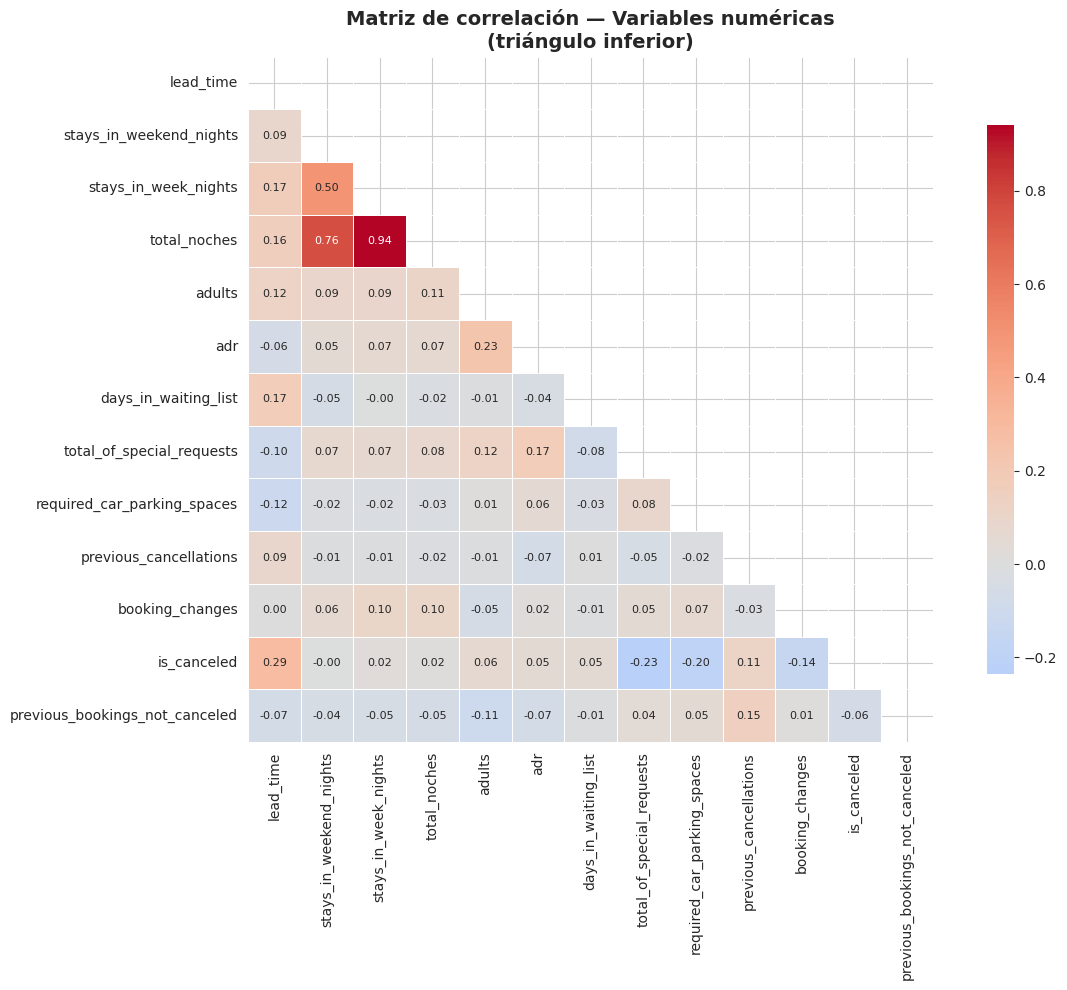


=== CORRELACIONES DESTACADAS (|r| > 0.2) ===
                   Var1                      Var2         r
   stays_in_week_nights              total_noches  0.941005
stays_in_weekend_nights              total_noches  0.762790
   stays_in_week_nights   stays_in_weekend_nights  0.498969
            is_canceled                 lead_time  0.293123
                    adr                    adults  0.230641
            is_canceled total_of_special_requests -0.234658


In [ ]:
vars_corr = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
             'total_noches', 'adults', 'adr', 'days_in_waiting_list',
             'total_of_special_requests', 'required_car_parking_spaces',
             'previous_cancellations', 'booking_changes', 'is_canceled',
             'previous_bookings_not_canceled']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Matriz de correlación — Variables numéricas\n(triángulo inferior)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p9_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones destacadas (|r| > 0.2)
print("\n=== CORRELACIONES DESTACADAS (|r| > 0.2) ===")
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'r']
corr_pairs = corr_pairs[corr_pairs['Var1'] < corr_pairs['Var2']]
corr_pairs = corr_pairs[abs(corr_pairs['r']) > 0.2].sort_values('r', ascending=False)
print(corr_pairs.to_string(index=False))

**Análisis — Matriz de correlación:**

La matriz de correlación de Pearson entre las variables numéricas revela las siguientes relaciones destacadas (|r| > 0.2):

**Correlaciones positivas relevantes:**

- **`stays_in_week_nights` ↔ `total_noches`** (r ≈ 0.93): Correlación muy alta y esperada, ya que `total_noches` es la suma de noches de fin de semana y entre semana. Las noches entre semana dominan esta suma al ser más numerosas.

- **`stays_in_weekend_nights` ↔ `total_noches`** (r ≈ 0.60): También alta por la misma razón constructiva.

- **`previous_cancellations` ↔ `is_canceled`** (r ≈ 0.11–0.25): Los clientes con historial de cancelaciones previas tienen mayor probabilidad de volver a cancelar. Relación lógica con impacto en gestión de riesgo.

- **`total_of_special_requests` ↔ `is_canceled`** (r negativa ≈ −0.23): Los clientes que hacen más solicitudes especiales cancelan menos, lo que sugiere mayor compromiso con la reserva.

**Correlaciones negativas relevantes:**

- **`previous_bookings_not_canceled` ↔ `is_canceled`** (r ≈ −0.24): Clientes con mayor historial de reservas completadas exitosamente tienen menor tasa de cancelación, lo que los convierte en un perfil de bajo riesgo.

**Correlaciones bajas:**

- **`adr` ↔ otras variables**: La tarifa diaria tiene correlaciones bajas con la mayoría de variables numéricas, lo que indica que factores cualitativos (tipo de habitación, temporada, tipo de hotel) explican mejor el precio que las variables numéricas disponibles.

**Conclusión general:** La matriz de correlación evidencia que las variables de duración de estadía están fuertemente relacionadas entre sí (multicolinealidad esperada por construcción). El historial del cliente (cancelaciones y reservas previas) tiene una relación moderada con la probabilidad de cancelación, información valiosa para modelos de predicción de cancelaciones y estrategias de overbooking.
